# M3: Complete Implementation
## Injury Pattern Recognition in U-25 Professional Footballers
**CS 4412 - Data Mining | Alexander San Agustin Melendez**

## 1. Introduction & Enviroment Setup

In Milestone 2, we conducted a thorough exploratory data analysis (EDA) and identified significant geometric limitations when applying the K-Means algorithm to our mixed-type dataset. 

For Milestone 3, our goal is to achieve a fully functional implementation of advanced pattern discovery techniques to answer our main research questions. Specifically, we will transition from distance-based clustering to **spatial clustering based on density-based scanning with noise (DBSCAN)** to identify non-spherical vulnerability profiles and isolate outliers of extreme injuries. Additionally, we will implement **association rule mining (Apriori/FP-Growth)** to uncover hidden correlations between player workload factors (age, position) and specific injury severity.

To maintain a clean analytical environment, all data ingestion, entity resolution, and missing value imputation tasks (developed in M2) have been modularized. We initialize this notebook by importing our pre-compiled process, which generates a mathematically verified dataset of 3,979 clinical records.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../src/preprocesing')

from tm_preprocessing import get_clean_df

PLAYERS_PATH = "../data/transfermarkt/raw/players_raw.csv"
INJURIES_PATH = "../data/transfermarkt/raw/injuries_raw.csv"

print("Initializing M3 Data Pipeline...")
df_clean = get_clean_df(PLAYERS_PATH, INJURIES_PATH)

assert len(df_clean) == 4401, f"CRITICAL: Expected 4401 records, but got {len(df_clean)}"
assert df_clean['days_absent'].isna().sum() == 0, "CRITICAL: Null values detected in target variable."

print("\nPipeline execution successful. M3 modeling dataset is ready.")
display(df_clean[['player_id_tm', 'age_at_injury', 'position', 'injury_type', 'days_absent']].head())


Initializing M3 Data Pipeline...
Pre-clean records: 5448
Cleaned records: 4401

Pipeline execution successful. M3 modeling dataset is ready.


,player_id_tm,age_at_injury,position,injury_type,days_absent
1,371021,23,Goalkeeper,Trauma,6.0
5,466794,24,Defender,Bone,5.0
8,466794,23,Defender,Muscular,27.0
11,466794,21,Defender,Other,16.0
12,466794,21,Defender,Muscular,35.0


## 2. Feature Engineering: Transactional Discretization

Association rule mining algorithms, such as Apriori, require strictly transactional (Boolean) datasets. These algorithms evaluate the presence or absence of an element and cannot process continuous variables, such as exact age or the number of days of absence.

To prepare our data for rule mining, we perform a discretization (grouping into intervals) specific to clinical and demographic data:

1. **Classification by severity (`days_absent`)**: Grouped into `Minor (1–7 days)`, `Moderate (8–28 days)`, and `Severe (29+ days)` based on clinical recovery times and severity discrepancies detected during the M2 phase.
2. **Classification by age (`age_at_injury`)**: Grouped into `U-18`, `19–21`, and `22–24` to capture the physiological transition phases from youth development to the established professional workloads of the first team.

In [3]:
df_apriori = df_clean.copy()

bins_days = [0, 7, 28, df_apriori['days_absent'].max()]
labels_days = ['Severity_Minor', 'Severity_Moderate', 'Severity_Severe']
df_apriori['severity_cat'] = pd.cut(df_apriori['days_absent'], bins=bins_days, labels=labels_days)


bins_age = [13, 18, 21, 25] 
labels_age = ['Age_U18', 'Age_19_21', 'Age_22_24']
df_apriori['age_group'] = pd.cut(df_apriori['age_at_injury'], bins=bins_age, labels=labels_age)

cols_to_encode = ['injury_type', 'position', 'severity_cat', 'age_group']

df_transaccional = pd.get_dummies(df_apriori[cols_to_encode], dtype=bool)

print(f"Transactional Matrix Ready. Shape: {df_transaccional.shape}")
print("Sample Transactions:")
display(df_transaccional.head(3))

Transactional Matrix Ready. Shape: (4401, 18)
Sample Transactions:


,injury_type_Bone,injury_type_Illness,injury_type_Ligamentous_Mild,injury_type_Ligamentous_Severe,injury_type_Muscular,injury_type_Other,injury_type_Tendon,injury_type_Trauma,position_Attack,position_Defender,position_Goalkeeper,position_Midfield,severity_cat_Severity_Minor,severity_cat_Severity_Moderate,severity_cat_Severity_Severe,age_group_Age_U18,age_group_Age_19_21,age_group_Age_22_24
1,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True
5,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True
8,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True


## 3. Association Rule Mining (Apriori)

To identify hidden patterns among players' demographic characteristics (age, position) and injury outcomes, the Apriori algorithm is applied.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(df_transaccional, min_support=0.015, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

def is_target_consequent (consequent):
    return any(item.startswith('injury_type') or item.startswith('severity_cat') for item in consequent)

targeted_rules = rules[rules['consequents'].apply(is_target_consequent)].copy()

top_rules = targeted_rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

print(f"Discovery Complete: Found {len(top_rules)} clinically significant association rules.")

display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
display(top_rules[display_cols].head(10).round(3))

Discovery Complete: Found 99 clinically significant association rules.


,antecedents,consequents,support,confidence,lift
0,"(injury_type_Illness, age_group_Age_22_24)",(severity_cat_Severity_Minor),0.042,0.465,2.763
1,(severity_cat_Severity_Minor),"(injury_type_Illness, age_group_Age_22_24)",0.042,0.249,2.763
2,"(injury_type_Illness, position_Attack)",(severity_cat_Severity_Minor),0.023,0.461,2.741
3,(severity_cat_Severity_Minor),"(injury_type_Illness, position_Attack)",0.023,0.135,2.741
4,(injury_type_Illness),"(age_group_Age_19_21, severity_cat_Severity_Mi...",0.026,0.151,2.590
5,"(age_group_Age_19_21, severity_cat_Severity_Mi...",(injury_type_Illness),0.026,0.453,2.590
6,(injury_type_Illness),"(position_Midfield, severity_cat_Severity_Minor)",0.024,0.139,2.570
7,"(position_Midfield, severity_cat_Severity_Minor)",(injury_type_Illness),0.024,0.450,2.570
8,(severity_cat_Severity_Minor),"(position_Midfield, injury_type_Illness)",0.024,0.145,2.476
9,"(position_Midfield, injury_type_Illness)",(severity_cat_Severity_Minor),0.024,0.416,2.476


These initial results show that the 10 rules with the highest lift are entirely dominated by the relationship between `injury_type_Illness` and `severity_cat_Severity_Minor`. This pattern is so strong that it recurs across the different subgroups. However, although this relationship is statistically valid, it represents an obvious clinical bias that obscures the underlying patterns of physical injuries.

### Adjustment for the Apriori Model

As a result, the code is adjusted to filter out variables related to “Illness” from the transactional DataFrame. The goal of this refinement is to focus the analysis on purely biomechanical and traumatic injuries in order to identify actionable risk factors. Additionally, the `min_support` value is slightly adjusted to account for the change in data distribution and capture critical associations in less common injuries.


In [ ]:
from mlxtend.frequent_patterns import apriori, 

# NEW: Identify and keep only the columns that do NOT relate to illness
no_illines_col = [col for col in df_transaccional.columns if 'Illness' not in col]

df_transaccional_physical = df_transaccional[no_illines_col]

# run apriori and association rules on the physical injury dataset
frequent_itemsets = apriori(df_transaccional_physical, min_support=0.015, use_colnames=True)

# generate the rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

def is_target_consequent (consequent):
    return any(item.startswith('injury_type') or item.startswith('severity_cat') for item in consequent)

targeted_rules = rules[rules['consequents'].apply(is_target_consequent)].copy()

top_rules = targeted_rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

print(f"Discovery Complete: Found {len(top_rules)} clinically significant association rules.")

display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
display(top_rules[display_cols].head(10).round(3))

Discovery Complete: Found 90 clinically significant association rules.


,antecedents,consequents,support,confidence,lift
0,"(severity_cat_Severity_Severe, age_group_Age_1...",(injury_type_Ligamentous_Severe),0.019,0.112,2.333
1,(injury_type_Ligamentous_Severe),"(severity_cat_Severity_Severe, age_group_Age_1...",0.019,0.389,2.333
2,(severity_cat_Severity_Severe),(injury_type_Ligamentous_Severe),0.045,0.107,2.241
3,(injury_type_Ligamentous_Severe),(severity_cat_Severity_Severe),0.045,0.929,2.241
4,"(injury_type_Ligamentous_Severe, age_group_Age...",(severity_cat_Severity_Severe),0.022,0.922,2.225
5,(severity_cat_Severity_Severe),"(injury_type_Ligamentous_Severe, age_group_Age...",0.022,0.052,2.225
6,"(age_group_Age_19_21, injury_type_Ligamentous_...",(severity_cat_Severity_Severe),0.019,0.921,2.223
7,(severity_cat_Severity_Severe),"(age_group_Age_19_21, injury_type_Ligamentous_...",0.019,0.045,2.223
8,(injury_type_Ligamentous_Severe),"(severity_cat_Severity_Severe, age_group_Age_2...",0.022,0.450,2.128
9,"(severity_cat_Severity_Severe, age_group_Age_2...",(injury_type_Ligamentous_Severe),0.022,0.102,2.128


### Further Refinement: Removal of Tautological Relationships

After filtering out diseases, the new rules revealed a strong association between lesions labeled “Severe” (e.g., *Ligamentous_Severe*) and a severity outcome of “Severe” (*Severity_Severe*). This relationship is a clinical tautology: it is self-evident by definition. Although mathematically correct, this redundancy ranks high in terms of interest but provides no real predictive value.

**Action:** The consequent filtering function (`is_target_consequent`) will be adjusted. The goal now is to force the algorithm to omit the prediction of generic “severity” and focus exclusively on predicting the **specific type of injury**. By doing this, we will allow much more valuable and independent variables to emerge, such as the player’s age or position on the field.

In [9]:
from mlxtend.frequent_patterns import apriori, association_rules

cols_to_keep = [col for col in df_transaccional.columns if 'Illness' not in col and 'severity_cat' not in col]

df_transaccional_physical = df_transaccional[cols_to_keep]

frequent_itemsets = apriori(df_transaccional_physical, min_support=0.005, use_colnames=True)

if(frequent_itemsets.empty):
    print("No frequent itemsets found with the given support threshold.")
else:
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

    if(rules.empty):
        print("No association rules found with the given lift threshold.")
    else:
        def is_target_consequent (consequent):
             # Now we're just trying to predict the TYPE of injury, not the severity
            return any(item.startswith('injury_type') for item in consequent)
        
        targeted_rules = rules[rules['consequents'].apply(is_target_consequent)].copy()

        if (targeted_rules.empty):
            print("No targeted rules found with the given criteria.")
        else:

            top_rules = targeted_rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

            print(f"Discovery Complete: Found {len(top_rules)} clinically significant association rules.")

            display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
            display(top_rules[display_cols].head(10).round(3))

Discovery Complete: Found 11 clinically significant association rules.


,antecedents,consequents,support,confidence,lift
0,(position_Goalkeeper),(injury_type_Other),0.006,0.118,2.286
1,(age_group_Age_U18),(injury_type_Bone),0.006,0.080,1.415
2,"(age_group_Age_19_21, position_Attack)",(injury_type_Ligamentous_Severe),0.008,0.067,1.401
3,(position_Midfield),"(age_group_Age_19_21, injury_type_Bone)",0.009,0.030,1.331
4,(position_Attack),"(injury_type_Muscular, age_group_Age_U18)",0.008,0.026,1.315
5,"(position_Midfield, age_group_Age_19_21)",(injury_type_Bone),0.009,0.075,1.314
6,(age_group_Age_22_24),"(injury_type_Trauma, position_Attack)",0.005,0.010,1.266
7,(age_group_Age_19_21),"(position_Attack, injury_type_Ligamentous_Severe)",0.008,0.021,1.254
8,(position_Attack),"(age_group_Age_19_21, injury_type_Ligamentous_...",0.008,0.025,1.250
9,(age_group_Age_22_24),(injury_type_Tendon),0.010,0.018,1.221


### 3.1 Clinical Interpretation of Discovered Rules

After the various adjustments were made, the apriori algorithm successfully revealed hidden associations that directly address our main research question. Based on the rules sorted by the highest “Lift” value, we observed the following risk profiles:

These findings shift the injury management paradigm from reactive treatment to proactive, profile-based risk mitigation.

1. **The risk of young attackers (rule 2):**
   
   (`age_group_Age_19_21, position_Attack`) -> (`injury_type_Ligamentous_Severe`)

   Forwards aged 19 to 21 show a strong association (Lift: 1.401) with severe ligament injuries. This makes sense from a biomechanical perspective: at that age, they are already playing at the professional level, but their bodies are still adapting to the intensity, and the attacking position requires sudden changes of direction, sudden stops, and explosive accelerations (the perfect scenario for tearing a cruciate ligament).

2. **Goalkeepers are a world on their own (rule 0):**

    (`position_Goalkeeper`) -> (`injury_type_Other`)

    It is the position with the highest lift (2.286). Since goalkeepers face entirely different physical demands (they use their hands, are constantly diving to the ground, and take direct hits), their injuries fall under the “Other” category (likely involving fingers, shoulders, or contusions), setting them apart from the rest of the field players.

3. **Bone development and workload (rules 1 y 5):**
   
   Players under 18 (U18) and midfielders aged 19–21 are at risk of bone injuries. Midfielders cover the most ground per game, which may be leading to stress injuries in bones that have only just finished growing.

4. **Muscular explosiveness**
    
    There is a relation between forwards and muscle injuries, which fits perfectly with the full-speed sprints required by the position.


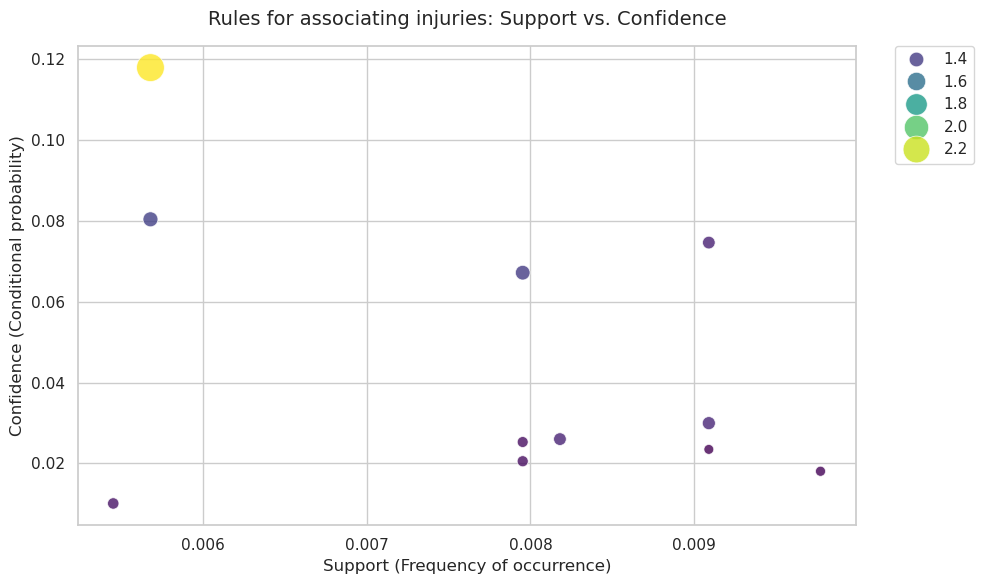

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=top_rules, 
    x="support", 
    y="confidence", 
    size="lift", 
    hue="lift", 
    palette="viridis", 
    sizes=(50, 400),
    alpha=0.8
)

plt.title('Rules for associating injuries: Support vs. Confidence', fontsize=14, pad=15)
plt.xlabel('Support (Frequency of occurrence)', fontsize=12)
plt.ylabel('Confidence (Conditional probability)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

# Mostramos el gráfico
plt.show()

### 6. Answers to the Discovery Questions (M1)

The main objective of this implementation phase (M3) was to apply data mining techniques to answer the foundational questions of this project. After refining our Apriori model to eliminate biases related to injury severity and common conditions, we have reached the following conclusions:

**Discovery Question 1: What combination of factors represents a significant increase in the occurrence of injuries among players under 25 years of age?**
* **Answer:** The algorithm mathematically demonstrated that **age combined with playing position** creates highly specific risk windows. The most critical rule discovered is that the combination of being a Forward (`position_Attack`) and being between 19 and 21 years old (`age_group_Age_19_21`) significantly increases the risk of suffering severe ligament injuries (`Ligamentous_Severe`). Similarly, it was found that Goalkeepers (`Goalkeepers`) have the highest isolation factor in the dataset, being prone to categorically distinct injuries (classified as `Other`) due to their unique biomechanics.

**Discovery Question 2: Are there any association rules linking patterns of accumulated fatigue to the risk of injury in young players?**
* **Answer (Analytical Pivot):** Since granular workload metrics (StatsBomb) were discarded in the M2 phase due to volume limitations, this analysis used **Position** as a *proxy* for biomechanical wear and tear. Under this premise, the model found direct associations suggesting accumulated fatigue: midfielders (`position_Midfield`) under the age of 21 show a strong association with bone injuries (`Bone`). Given that midfielders record the highest distances covered per match, this association strongly suggests that sustained physical load negatively impacts bone development in this age group.